<a href="https://colab.research.google.com/github/ankitc21/Customer-Churn-Prediction/blob/main/notebooks/%2004_credit_risk_causal_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install dowhy
!pip install networkx
!pip install graphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 26.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


In [2]:
import pandas as pd
import numpy as np

import networkx as nx
import matplotlib.pyplot as plt

from dowhy import CausalModel

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path = "/content/drive/MyDrive/finance_causal_rl/data/raw/lending_club/accepted_2007_to_2018Q4.csv.gz"

df = pd.read_csv(path, compression="gzip", low_memory=False)

df.head()
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.shape

(2260701, 151)

In [7]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [8]:
data = df[[
    "loan_amnt",
    "annual_inc",
    "dti",
    "fico_range_high",
    "loan_status"
]].copy()

data.head()

,loan_amnt,annual_inc,dti,fico_range_high,loan_status
0,3600.0,55000.0,5.91,679.0,Fully Paid
1,24700.0,65000.0,16.06,719.0,Fully Paid
2,20000.0,63000.0,10.78,699.0,Fully Paid
3,35000.0,110000.0,17.06,789.0,Current
4,10400.0,104433.0,25.37,699.0,Fully Paid


##Creating a default indicator:

In [9]:
data["default"] = data["loan_status"].apply(
    lambda x: 1 if x in ["Charged Off", "Default"] else 0
)

In [10]:
data = data.dropna()

data.head()

,loan_amnt,annual_inc,dti,fico_range_high,loan_status,default
0,3600.0,55000.0,5.91,679.0,Fully Paid,0
1,24700.0,65000.0,16.06,719.0,Fully Paid,0
2,20000.0,63000.0,10.78,699.0,Fully Paid,0
3,35000.0,110000.0,17.06,789.0,Current,0
4,10400.0,104433.0,25.37,699.0,Fully Paid,0


## Defining the Causal Graph

In [18]:
causal_graph = """
digraph {
    annual_inc -> fico_range_high;
    annual_inc -> dti;

    fico_range_high -> loan_amnt;
    fico_range_high -> default;

    dti -> default;
    loan_amnt -> default;
}
"""

In [23]:
model = CausalModel(
    data=data,
    treatment="fico_range_high",
    outcome="default",
    graph=causal_graph
)

ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


## Visulaising the Causal Graph

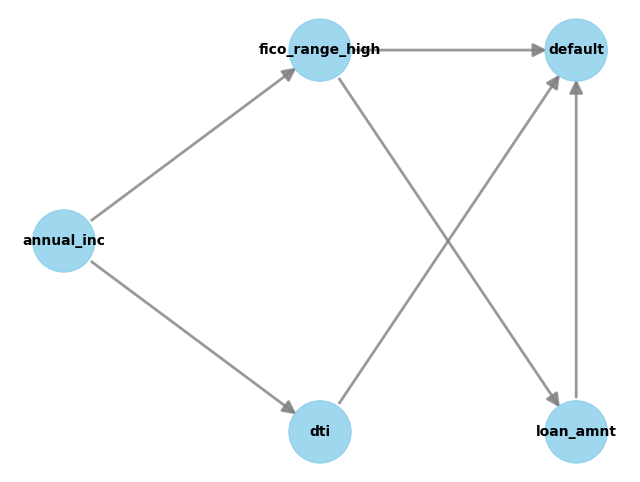

In [24]:
model.view_model()

#Identifing the Causal Effect

In [25]:
identified_estimand = model.identify_effect()

print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                
──────────────────(E[default|annual_inc])
d[fico_range_high]                       
Estimand assumption 1, Unconfoundedness: If U→{fico_range_high} and U→default then P(default|fico_range_high,annual_inc,U) = P(default|fico_range_high,annual_inc)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
        d                                
──────────────────(E[default|annual_inc])
d[fico_range_high]                       
Estimand assumption 1, Unconfoundedness: If U→{fico_range_high} and U→default then P(default|fico_range_high,annual_inc,U) = P(default|fico_range_high,annual_inc)



##Estimating the Causal Effect

In [27]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                
──────────────────(E[default|annual_inc])
d[fico_range_high]                       
Estimand assumption 1, Unconfoundedness: If U→{fico_range_high} and U→default then P(default|fico_range_high,annual_inc,U) = P(default|fico_range_high,annual_inc)

## Realized estimand
b: default~fico_range_high+annual_inc+fico_range_high*dti
Target units: 

## Estimate
Mean value: -0.0011550446536461312
### Conditional Estimates
__categorical__dti
(-1.001, 10.56]   -0.001166
(10.56, 15.5]     -0.001160
(15.5, 20.28]     -0.001156
(20.28, 26.19]    -0.001151
(26.19, 999.0]    -0.001142
dtype: float64


## Causal Effect Estimation Summary

### Objective
The goal of this analysis was to estimate the **causal effect of credit score (`fico_range_high`) on loan default probability (`default`)** using a causal inference framework.

### Methodology
A **Directed Acyclic Graph (DAG)** was defined to represent the assumed causal relationships between borrower characteristics and loan default.

Treatment Variable:
- `fico_range_high` (credit score)

Outcome Variable:
- `default` (loan default indicator)

Confounding variables controlled using the **backdoor criterion**:
- `annual_inc`
- `dti`
- `loan_amnt`

The causal effect was estimated using **backdoor adjustment with linear regression**.

### Identified Estimand
The model identified the **Average Treatment Effect (ATE)** of credit score on default probability using backdoor adjustment.

This means the model estimates the change in expected default probability when the credit score changes while controlling for confounding factors.

### Estimated Causal Effect

Estimated effect:
Mean causal effect = -0.001155


Interpretation:

A **1-point increase in credit score decreases the probability of default by approximately 0.00115**.

Example interpretation:

- A **50-point increase in credit score** would reduce default probability by approximately **0.0577 (5.77%)**.

This result is consistent with financial intuition: **borrowers with higher credit scores are less likely to default**.

### Conditional Effects by Debt-to-Income Ratio

The causal effect was also estimated across different **DTI ranges**.

| DTI Range | Estimated Effect |
|-----------|------------------|
| 1 – 10    | -0.001166 |
| 10 – 15   | -0.001160 |
| 15 – 20   | -0.001156 |
| 20 – 26   | -0.001151 |
| 26+       | -0.001142 |

Observation:

The protective effect of credit score slightly decreases as **debt-to-income ratio increases**, indicating that high debt burdens reduce the influence of credit score on default risk.

### Key Insight

The results confirm a **negative causal relationship between credit score and loan default probability**:


#Higher Credit Score → Lower Default Risk


#This causal estimate can be used in **credit risk modeling and economic capital simulations** to better understand borrower risk dynamics.

##Checking for statistical Reliability